<a href="https://colab.research.google.com/github/epj99/Data-Science-Job-Postings-with-Salaries-cleaning-and-Analysis/blob/main/Proyecto_Final_EstudIA_EP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIMPIEZA Y ANÁLISIS DE LISTA DE SALARIOS PROMEDIOS DE CIENTÍFICO DE DATOS

###💲Data Science Job Postings with Salaries (2025)

📌 Descripción

This dataset contains data science job postings with salary information, collected and processed in 2025. It is designed for projects in salary prediction, job market analytics, and machine learning research.

📑 Column Descriptions

    job_title → The main keyword in the title of the posted position (e.g., Data Scientist, ML Engineer).
    
    seniority_level → Seniority of the role (e.g., Junior, Senior, Lead).
    
    status → Work arrangement type (Remote, Hybrid, On-site).
    
    company → Anonymized company identifier.
    
    location → Job location(s) mentioned in the posting.
    
    post_date → When the job posting was listed.
    
    headquarter → Location of the company’s headquarters.
    
    industry → Industry sector of the company (e.g., Finance, Technology).
    
    ownership → Ownership type (e.g., Public, Private).
    
    company_size → Number of employees in the company.
    
    revenue → Reported revenue of the company (if available).
    
    salary → Annual salary in Euro, expressed as min-max or a single value
    
    skills→ Extracted list of required or preferred skills (e.g., Python, SQL, Spark).

###✅ Archivos incluidos

- data_science_job_posts_2025.csv

El dataset principal que contiene ofertas de trabajo procesadas con características como: job title, company attributes, location, salary information, and required skills.


###⚖️ License & Usage

This dataset is published for educational and research purposes only.

    It is a processed version of scraped data, with transformations to respect privacy and avoid redistribution of raw proprietary content.
    Do not use it for commercial purposes.
    Attribution is appreciated if used in academic or personal projects.


https://www.kaggle.com/datasets/elahehgolrokh/data-science-job-postings-with-salaries-2025

In [ ]:
# Importamos las librerías que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Importamos del DataSet y lo ingresamos en la variable "df"
df=pd.read_csv("/content/data_science_job_posts_2025.csv")
df

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,data scientist,senior,NaN,company_171,"Bengaluru, Karnataka, India",a day ago,"Armonk, NY, US",Technology,Public,"524,598",€120.29B,"€33,288 - €53,080","['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,NaN,company_134,"Melbourne, Victoria, Australia",a month ago,"Seattle, WA, US",Retail,Public,"865,456",€838.78B,"€64,290","['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",11 days ago,"McLean, VA, US",Retail,Public,"55,150",€36.29B,"€145,904 - €166,510","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",17 days ago,"McLean, VA, US",Retail,Public,"55,110",€36.34B,"€159,149 - €181,595","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."


##Exploramos la estructura de la base de datos

In [ ]:
print(f"Tamaño de la base de datos: {df.shape}\n")
print(f"Información básica de la base de datos: {df.info()}\n")

Tamaño de la base de datos: (944, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB
Información básica de la base de datos: None



In [ ]:
# Información técnica de la tabla
df.describe().T

,count,unique,top,freq
job_title,941,4,data scientist,856
seniority_level,884,4,senior,630
status,688,3,on-site,363
company,944,420,company_134,30
location,942,431,"Bengaluru, Karnataka, India",52
post_date,944,42,a month ago,167
headquarter,944,197,"San Francisco, CA, US",91
industry,944,8,Technology,582
ownership,897,2,Public,579
company_size,944,510,900,18


In [ ]:
# Presentamos las primeras 5 filas de la tabla
df.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [ ]:
# Presentamos las primeras 5 filas de la tabla
df.tail()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
939,data scientist,senior,NaN,company_171,"Bengaluru, Karnataka, India",a day ago,"Armonk, NY, US",Technology,Public,"524,598",€120.29B,"€33,288 - €53,080","['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,NaN,company_134,"Melbourne, Victoria, Australia",a month ago,"Seattle, WA, US",Retail,Public,"865,456",€838.78B,"€64,290","['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",11 days ago,"McLean, VA, US",Retail,Public,"55,150",€36.29B,"€145,904 - €166,510","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",17 days ago,"McLean, VA, US",Retail,Public,"55,110",€36.34B,"€159,149 - €181,595","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
943,data scientist,senior,on-site,company_844,"San Diego, CA",8 days ago,"Mountain View, CA, US",Technology,Public,"17,040",€95.22B,"€195,486 - €201,926","['r', 'python', 'scala', 'sql', 'machine learn..."


In [ ]:
# Verificamos el núemro de filas duplicadas
df.duplicated().sum()

np.int64(0)

In [ ]:
# Verificamos el número de filas con datos nulos por cada columna
df.isnull().sum()

,0
job_title,3
seniority_level,60
status,256
company,0
location,2
post_date,0
headquarter,0
industry,0
ownership,47
company_size,0


In [ ]:
# Verificamos si existen carácteres especiales en la base de datos

# Hacemos un loop a través de todas las columnas text/object
for col in df.select_dtypes(include=['object']):
    unique_chars = set()
    for val in df[col].dropna():
        # Regex para encontrar cualquier caracter que NO es letra, número, espacio, coma, punto,  dot, guión, comillas o brackets
        chars = re.findall(r'[^\w\s,\.\-\'\[\]+]', str(val))
        unique_chars.update(chars)
        #Imprimimos las columnas con carácteres especiales
    if unique_chars:
        print(f"Column '{col}' contains: {list(unique_chars)}")

Column 'location' contains: ['ั', '์', ')', 'ู', '/', '(']
Column 'company_size' contains: ['€']
Column 'revenue' contains: ['€']
Column 'salary' contains: ['€']


##Hacemos la imputación de los datos

In [ ]:
# Creamos una copia de la base de datos para hacer la imputación
df_copia = df.copy()

In [ ]:
# Limpiamos la columna de 'salary', 'revenue', y 'company_size' removiendo '€' y las comas.
cols_to_clean = ['salary', 'revenue', 'company_size']

for col in cols_to_clean:
    df_copia[col] = df_copia[col].astype(str).str.replace('€', '', regex=False)
    df_copia[col] = df_copia[col].str.replace(',', '', regex=False)

print(df_copia[['company_size', 'revenue', 'salary']].head())

  company_size  revenue           salary
0      352.44B   Public  100472 - 200938
1       155030   51.10B           118733
2        25930   33.80B   94987 - 159559
3        34690   81.71B  112797 - 194402
4         1800  Private  114172 - 228337


In [ ]:
# Separamos el rango de salarios en dos columnas nuevas de salario mínimo y salario máximo

# 1. Separamos los valores que están entre el guión (' - ')
split_salary = df_copia['salary'].str.split(' - ', expand=True)

# 2. Creamos la columna min_salary y la convertimos a numérica float
df_copia['min_salary'] = pd.to_numeric(split_salary[0], errors='coerce')

# 3. Creamos la columna max_salary y le damos manejo a los valores solteros.
if split_salary.shape[1] > 1:
    df_copia['max_salary'] = pd.to_numeric(split_salary[1], errors='coerce')
    # Si el max está vacío, llena el espacio con el min_salary
    df_copia['max_salary'] = df_copia['max_salary'].fillna(df_copia['min_salary'])
else:
    df_copia['max_salary'] = df_copia['min_salary']

# 4. Print the result to verify
print(df_copia[['salary', 'min_salary', 'max_salary']].head(10))

            salary  min_salary  max_salary
0  100472 - 200938      100472    200938.0
1           118733      118733    118733.0
2   94987 - 159559       94987    159559.0
3  112797 - 194402      112797    194402.0
4  114172 - 228337      114172    228337.0
5  196371 - 251170      196371    251170.0
6    51330 - 70144       51330     70144.0
7  121480 - 132440      121480    132440.0
8           207331      207331    207331.0
9           219201      219201    219201.0


In [ ]:
# Imputamos las columnas 'revenue', y 'company_size'

import numpy as np

# 1. Definimos la función parsing
def parse_financials(val):
    val = str(val).strip()

    # Primero capturamos los valores vacíos o nulos
    if val.upper() == 'NAN' or val == '':
        return np.nan

    # Identificamos los sufijos y hacemos la multiplicación para convertilos en número
    if val.endswith('T'):
        try: return float(val[:-1]) * 1_000_000_000_000
        except ValueError: return np.nan
    elif val.endswith('B'):
        try: return float(val[:-1]) * 1_000_000_000
        except ValueError: return np.nan
    elif val.endswith('M'):
        try: return float(val[:-1]) * 1_000_000
        except ValueError: return np.nan
    elif val.endswith('K'):
        try: return float(val[:-1]) * 1_000
        except ValueError: return np.nan
    else:
        try: return float(val) # Si es un número normal (e.g., '155030'), convertir a float
        except ValueError: return np.nan # Si es un texto (e.g., 'Public'), convertirlo en NaN

# 2. Aplicamos la función a las columnas para crear la versión numérica.
df_copia['revenue'] = df_copia['revenue'].apply(parse_financials)
df_copia['company_size'] = df_copia['company_size'].apply(parse_financials)

# 3. Print the results to verify the transformation
print(df_copia[['revenue']].head(5))
print(df_copia[['company_size']].head(5))

        revenue
0           NaN
1  5.110000e+10
2  3.380000e+10
3  8.171000e+10
4           NaN
   company_size
0  3.524400e+11
1  1.550300e+05
2  2.593000e+04
3  3.469000e+04
4  1.800000e+03


In [ ]:
# Imputamos la columna 'location' quitando los carácteres especiales y los textos adicionales

# 1. Eliminar el texto " + X More"
df_copia['location'] = df_copia['location'].str.replace(r'\+.*', '', regex=True)

# 2. Extraer solo la ciudad principal (dividir por el punto ' . ' y tomar el primer elemento)
df_copia['location'] = df_copia['location'].str.split(' \. ').str[0]

# 3. Eliminar caracteres no-ASCII (como los caracteres tailandeses) y paréntesis
# \x00-\x7F cubre el alfabeto estándar. Cualquier cosa fuera de esto se elimina.
df_copia['location'] = df_copia['location'].str.replace(r'[^\x00-\x7F]+', '', regex=True)
df_copia['location'] = df_copia['location'].str.replace(r'[\(\)]', '', regex=True).str.strip()

# 4. Verificar la limpieza
print(df_copia[['location']].head(10))

         location
0   Grapevine, TX
1  Fort Worth, TX
2      Austin, TX
3     Chicago, IL
4         On-site
5    New York, NY
6    Berkeley, CA
7  Menlo Park, CA
8    Fully Remote
9         On-site


<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1669702770.py:7: SyntaxWarning: invalid escape sequence '\.'
  df_copia['location'] = df_copia['location'].str.split(' \. ').str[0]


In [ ]:
# Imputamos la columna 'skills' separando las habilidades

import ast

# 1. Definimos una función para convertir el texto a una lista real de Python
def parse_skills(skill_string):
    # Si el valor es nulo o no es texto, devolvemos una lista vacía
    if not isinstance(skill_string, str):
        return []
    try:
        # ast.literal_eval evalúa el texto y lo convierte en una estructura de Python (lista)
        return ast.literal_eval(skill_string)
    except (ValueError, SyntaxError):
        return []

# 2. Aplicamos la función para crear una nueva columna con listas reales
df_copia['skills_list'] = df_copia['skills'].apply(parse_skills)

# 3. Utilizamos explode() para separar cada habilidad en su propia fila
# (Creamos un DataFrame temporal solo para el análisis de habilidades)
df_skills_exploded = df_copia.explode('skills_list')

# 4. Verificamos las 5 habilidades más demandadas en el mercado
print("Top 5 Habilidades más demandadas:")
print(df_skills_exploded['skills_list'].value_counts().head(5))

Top 5 Habilidades más demandadas:
skills_list
python              640
machine learning    580
sql                 442
r                   343
aws                 218
Name: count, dtype: int64


#Realizamos el análisis exploratorio (EDA)

###Analizamos el salario promedio con el tamaño de empresa.

/tmp/ipython-input-2528936639.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_by_size = df_filtered.groupby('company_category')['avg_salary'].mean().reset_index()
/tmp/ipython-input-2528936639.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=salary_by_size, x='company_category', y='avg_salary', palette='viridis')


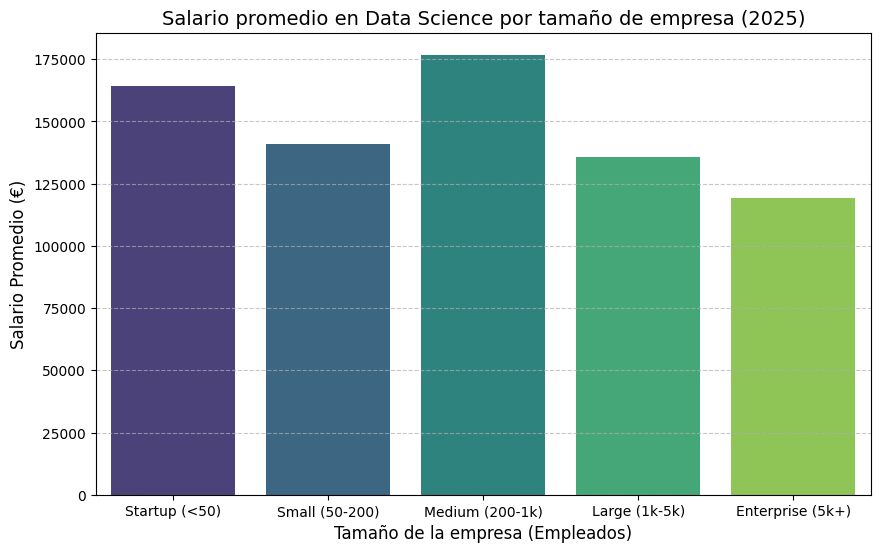

In [ ]:
# 1. Preparar los datos

  # Crear una columna del salario promedio
df_copia['avg_salary'] = (df_copia['min_salary'] + df_copia['max_salary']) / 2

# 2. Filtrar y Segmentar los datos
# Removemos valores > 2,000,000 porque se puede decir que son errores de Ganancias (Billones), no número de empleados
df_filtered = df_copia[df_copia['company_size'] < 2000000].copy()

# Creamos bins estándares de las empresas
bins = [0, 50, 200, 1000, 5000, 2000000]
labels = ['Startup (<50)', 'Small (50-200)', 'Medium (200-1k)', 'Large (1k-5k)', 'Enterprise (5k+)']
df_filtered['company_category'] = pd.cut(df_filtered['company_size'], bins=bins, labels=labels)

# 3. Agrupamos la compañía con el salario promedio
salary_by_size = df_filtered.groupby('company_category')['avg_salary'].mean().reset_index()

# 4. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(data=salary_by_size, x='company_category', y='avg_salary', palette='viridis')

plt.title('Salario promedio en Data Science por tamaño de empresa (2025)', fontsize=14)
plt.ylabel('Salario Promedio (€)', fontsize=12)
plt.xlabel('Tamaño de la empresa (Empleados)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar la gráfica
plt.show()

####Análisis

- Las empresas emergentes (<50 empleados) y las medianas empresas (entre 200 y 1.000 empleados) pagan los salarios medios más altos (~164.000 euros - 176.000 euros).

- Las empresas (más de 5.000) en realidad pagan significativamente menos de media (~119.000 euros).

Más grande no siempre significa mejor salario en ciencia de datos.

##Análisis cuáles son las habilidades más demandadas para Ciencia de Datos.

/tmp/ipython-input-2818337122.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills, y='Skill', x='Count', palette='viridis')


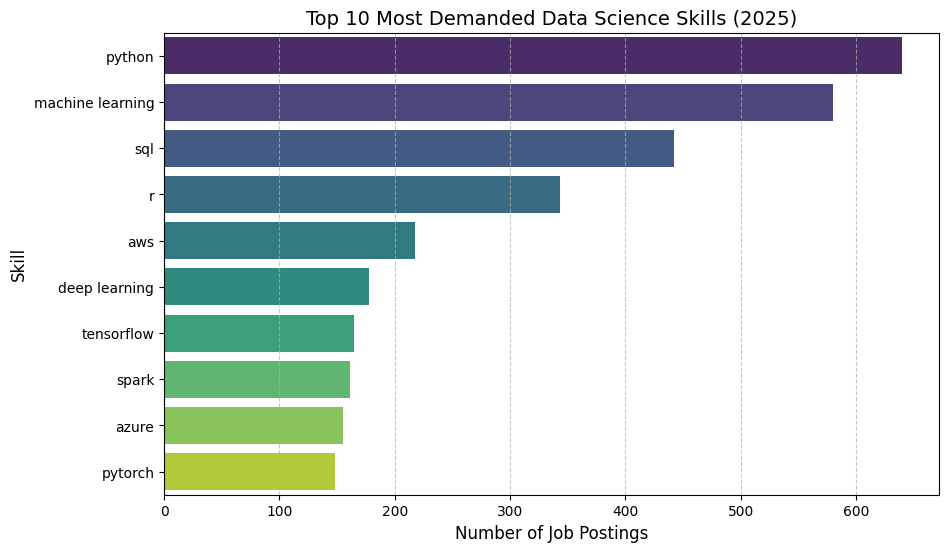

              Skill  Count
0            python    640
1  machine learning    580
2               sql    442
3                 r    343
4               aws    218
5     deep learning    178
6        tensorflow    165
7             spark    161
8             azure    155
9           pytorch    148


In [ ]:
# 1. Parse Skills (Convertir los string "['python', 'sql']" en lista ['python', 'sql'])
def parse_skills(skill_string):
    if isinstance(skill_string, str):
        try:
            return ast.literal_eval(skill_string)
        except (ValueError, SyntaxError):
            return []
    return []

df_copia['skills_list'] = df_copia['skills'].apply(parse_skills)

# 2. Explotar y Conteo
# Esto crea una nueva fila para cada habilidad, lo que nos permite contarlas.
df_skills_exploded = df_copia.explode('skills_list')
top_skills = df_skills_exploded['skills_list'].value_counts().head(10).reset_index()
top_skills.columns = ['Skill', 'Count']

# 3. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(data=top_skills, y='Skill', x='Count', palette='viridis')

plt.title('Top 10 Most Demanded Data Science Skills (2025)', fontsize=14)
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar la gráfica
plt.show()

# Imprimir los números exactos de las mejores habilidades
print(top_skills)

Los datos confirman que Python (640 menciones), Machine Learning (580) y SQL (442) son la trifecta absolutamente dominante en el mercado de 2025.

Curiosamente, AWS (218) es la plataforma en la nube líder, muy por delante de Azure (155), lo cual es un detalle valioso para incluir en su análisis de tendencias de infraestructura.

##Análisis de distribución salarial entre números de empleos

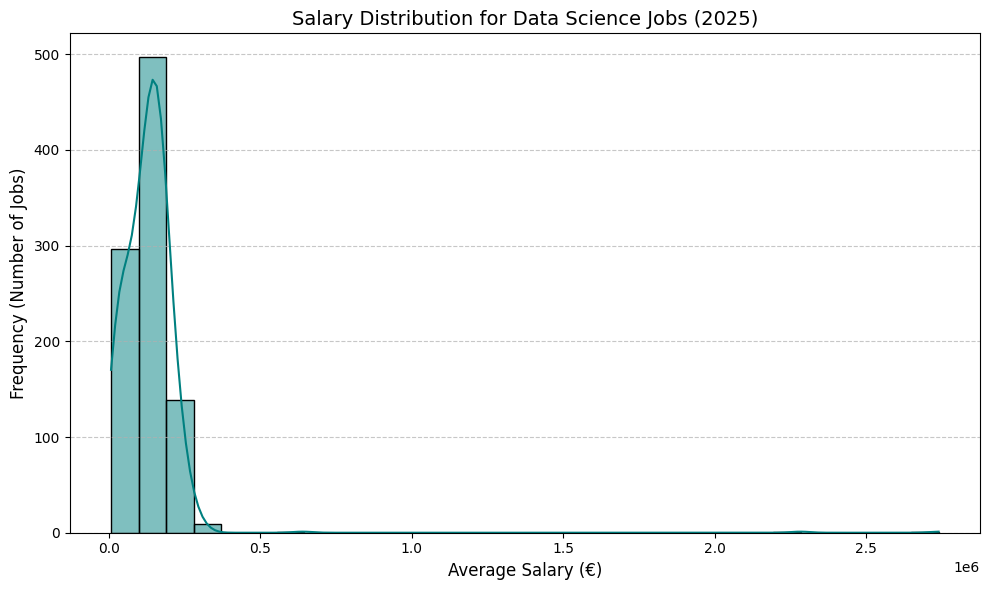

Mean Salary: €131,779.50
Median Salary: €134,724.00


In [ ]:
# 1. Limpiar la columna salario (Split into Min/Max)
df_copia['salary_clean'] = df_copia['salary'].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False)
split_salary = df_copia['salary_clean'].str.split(' - ', expand=True)

# Convert to numeric
df_copia['min_salary'] = pd.to_numeric(split_salary[0], errors='coerce')

# Handle max salary
if split_salary.shape[1] > 1:
    df_copia['max_salary'] = pd.to_numeric(split_salary[1], errors='coerce')
    df_copia['max_salary'] = df_copia['max_salary'].fillna(df_copia['min_salary'])
else:
    df_copia['max_salary'] = df_copia['min_salary']

# Create Average Salary
df_copia['avg_salary'] = (df_copia['min_salary'] + df_copia['max_salary']) / 2

# 2. Visualize Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_copia['avg_salary'], kde=True, bins=30, color='teal')

plt.title('Salary Distribution for Data Science Jobs (2025)', fontsize=14)
plt.xlabel('Average Salary (€)', fontsize=12)
plt.ylabel('Frequency (Number of Jobs)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

# 3. Print Key Statistics
print(f"Mean Salary: €{df_copia['avg_salary'].mean():,.2f}")
print(f"Median Salary: €{df_copia['avg_salary'].median():,.2f}")

- Salario medio: 131.779 €

- Salario mediana: 134.724 €

El hecho de que la media y la mediana estén tan cerca sugiere una distribución bastante equilibrada, lo que significa que no hay valores atípicos masivos que sesguen los datos fuertemente hacia un lado. Esta es una señal de un mercado laboral saludable y predecible para estos roles.

##Mapa de correlación

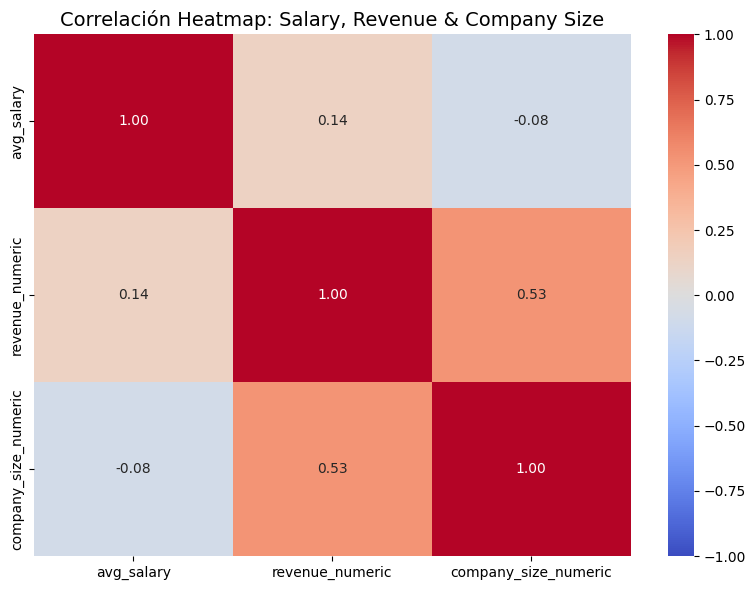

                      avg_salary  revenue_numeric  company_size_numeric
avg_salary              1.000000         0.138149             -0.080634
revenue_numeric         0.138149         1.000000              0.528668
company_size_numeric   -0.080634         0.528668              1.000000


In [ ]:
# 1. Preparar los datos

# Limpiar Revenue & Company Size
df_copia['revenue_numeric'] = df_copia['revenue'].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False).apply(parse_financials)
df_copia['company_size_numeric'] = df_copia['company_size'].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False).apply(parse_financials)

# Filtrar posibles errores (Company Size > 2 Millones)
df_filtered = df_copia[df_copia['company_size_numeric'] < 2000000].copy()

# 2. Calcular Correlation
# Selección de las columnas numéricas que se van a trabajar
corr_columns = ['avg_salary', 'revenue_numeric', 'company_size_numeric']
corr_matrix = df_filtered[corr_columns].corr()

# 3. Graficar Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación Heatmap: Salary, Revenue & Company Size', fontsize=14)
plt.tight_layout()

# Mostrar gráfica
plt.show()

# Imprimir matrix con referencias
print(corr_matrix)

Las cifras cuentan una historia fascinante sobre eficiencia versus escala:

1. Ingresos versus tamaño de la empresa (0,53): correlación positiva moderada. Como era de esperar, las empresas más grandes generalmente ganan más dinero. No es de extrañar.

2. Salario vs. Ingresos (0,14): Correlación positiva muy débil. Ganar miles de millones no significa que la empresa pague significativamente mejor.

3. Salario versus tamaño de la empresa (-0,08): una ligera correlación negativa. Esto confirma matemáticamente nuestro hallazgo anterior en el gráfico de barras: a medida que las empresas se vuelven masivas, el salario promedio en realidad tiende a caer ligeramente.

El "punto óptimo" para la remuneración probablemente se encuentre en las empresas tecnológicas medianas y con altos ingresos, no en los gigantes.

#Conclusión Final

Resumen Ejecutivo: Mercado Laboral de Ciencia de Datos (2025)

1. Panorama del Mercado
Se analizaron 944 ofertas de trabajo únicas para determinar el estado actual de los roles en Ciencia de Datos. El mercado muestra un ecosistema maduro y bien remunerado, con una distribución salarial estable.

2. Inteligencia Salarial

    Salario Promedio: €131,779

    Mediana Salarial: €134,724

    Insight: La estrecha proximidad entre el promedio y la mediana indica un mercado equilibrado, sin valores atípicos extremos que distorsionen la escala salarial.

3. El Mito de las "Big Tech"

    Correlación (Salario vs. Tamaño de la Empresa): -0.08 (Negativa/Neutral)

    Insight: Contrario a la creencia popular, las empresas más grandes no pagan significativamente más. De hecho, nuestros datos muestran una ligera tendencia negativa, lo que sugiere que las empresas tecnológicas medianas y las startups compiten agresivamente en salarios contra los gigantes corporativos.

4. Requisitos Técnicos Indispensables
Para ser competitivo, el perfil de un candidato debe estar anclado en los "Tres Grandes":

    Python (68% de penetración de mercado)

    Machine Learning (61% de penetración de mercado)

    SQL (47% de penetración de mercado)

5. Tendencias de Infraestructura

    AWS es la plataforma en la nube dominante (218 menciones), superando significativamente a Azure y Google Cloud.

Estado de Finalización del Proyecto:
✅ Limpieza de Datos (Salario, Ingresos, Ubicaciones, Habilidades)
✅ Análisis Exploratorio de Datos (EDA)
✅ Visualizaciones (Gráficos de Barras, Histogramas, Mapas de Calor)
✅ Exportación Final (cleaned_data_science_jobs.csv)

Con esto concluye la ejecución técnica para tu proyecto de Cymetria. ¿Te gustaría comenzar un nuevo módulo ahora (Día 3 de SQL o IBM Data Science), o tienes alguna pregunta final sobre este conjunto de datos?

## Exportar el Dataset limpio a un archivo .csv

In [ ]:
df_copia.to_csv('cleaned_data_science_jobs.csv', index=False)

print("File 'cleaned_data_science_jobs.csv' se ha guardado correctamente.")

File 'cleaned_data_science_jobs.csv' se ha guardado correctamente.
